In [351]:
from sklearn.preprocessing import RobustScaler, StandardScaler
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [352]:
from data_load import scaled_data, raw_data, result, data_info
from autoencoder_hy import AutoEncoder

In [353]:
raw_data.head()

,idx,Machine_Name,Item No,working time,Thickness 1(mm),Thickness 2(mm),weld force(bar),weld current(kA),weld Voltage(v),weld time(ms)
0,1,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.33,14.57,2.701,72.0
1,2,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.57,2.701,72.0
2,3,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,71.0
3,4,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.37,14.54,2.703,72.0
4,5,Spot-01,65235-25800,2020-03-24,0.7,0.7,2.36,14.56,2.704,72.0


In [354]:
# Thickness는 모두 같은 값이므로 예측에 영향 X

print(np.sum(raw_data['Thickness 1(mm)'] != 0.7))
print(np.sum(raw_data['Thickness 2(mm)'] != 0.7))

0
0


In [355]:
# 쓸모없는 열 제외
raw_data_clean = raw_data.iloc[:, 6:].copy()

# 새로우 피쳐 추가
# raw_data_clean['power'] = (
#     raw_data_clean['weld current(kA)']
#     * raw_data_clean['weld Voltage(v)']
# )
# raw_data_clean['energy'] = (
#     raw_data_clean['power']
#     * raw_data_clean['weld time(ms)']
#     / 1000
# )

split = 8470

# train, test 셋 구분
train_data = raw_data_clean.iloc[:split]
test_data = raw_data_clean.iloc[split:]

print(f'Data_columns : {train_data.columns}')
print(f'Train data : {len(train_data)}, Test data : {len(test_data)}')

Data_columns : Index(['weld force(bar)', 'weld current(kA)', 'weld Voltage(v)',
       'weld time(ms)'],
      dtype='str')
Train data : 8470, Test data : 3469


In [356]:
# 결함 갯수 비교
split = result['working time'].searchsorted(pd.Timestamp('2020-04-02'))

undercut_train_idx = result.iloc[:split]['defect type'] == 1
lack_train_idx = result.iloc[:split]['defect type'] == 2
crack_train_idx = result.iloc[:split]['defect type'] == 3

undercut_test_idx = result.iloc[split:]['defect type'] == 1
lack_test_idx = result.iloc[split:]['defect type'] == 2
crack_test_idx = result.iloc[split:]['defect type'] == 3

defect_train = pd.Series(result.iloc[:split]['defect'], dtype=int)
defect_test = pd.Series(result.iloc[split:]['defect'], dtype=int)
print(f'훈련 데이터 이상치 갯수 \n'
      f'파임불량 : {np.sum(defect_train[undercut_train_idx])}\n'
      f'용접부족 : {np.sum(defect_train[crack_train_idx])}\n'
      f'크랙발생 : {np.sum(defect_train[lack_train_idx])}\n'
      f'총 결함 수 : {np.sum(defect_train[undercut_train_idx]) + np.sum(defect_train[crack_train_idx]) + np.sum(defect_train[lack_train_idx])}\n')

print(f'테스트 데이터 이상치 갯수 \n'
      f'파임불량 : {np.sum(defect_test[undercut_test_idx])}\n'
      f'용접부족 : {np.sum(defect_test[crack_test_idx])}\n'
      f'크랙발생 : {np.sum(defect_test[lack_test_idx])}\n'
      f'총 결함 수 : {np.sum(defect_test[undercut_test_idx]) + np.sum(defect_test[crack_test_idx]) + np.sum(defect_test[lack_test_idx])}')

훈련 데이터 이상치 갯수 
파임불량 : 11
용접부족 : 7
크랙발생 : 10
총 결함 수 : 28

테스트 데이터 이상치 갯수 
파임불량 : 3
용접부족 : 5
크랙발생 : 3
총 결함 수 : 11


In [357]:
# 데이터 정규화

scaler = RobustScaler()

train_scaled = scaler.fit_transform(train_data).astype(np.float32)
test_scaled = scaler.transform(test_data).astype(np.float32)

train_scaled = pd.DataFrame(
    train_scaled,
    columns=train_data.columns,
    index=train_data.index
)

test_scaled = pd.DataFrame(
    test_scaled,
    columns=test_data.columns,
    index=test_data.index
)

train_scaled.head(3)

train_tensor = torch.tensor(train_scaled.to_numpy(), dtype=torch.float32)
test_tensor = torch.tensor(test_scaled.to_numpy(), dtype=torch.float32)

train_loader = DataLoader(
    TensorDataset(train_tensor),
    batch_size=64,
    shuffle=False
)
test_loader = DataLoader(
    TensorDataset(test_tensor),
    batch_size=64,
    shuffle=False
)

In [369]:
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

input_size = train_tensor.shape[1]
latent_size = 2
hidden_size = (8, 4)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
autoencoder = AutoEncoder(input_size, latent_size, hidden_size).to(device)
optimizer = torch.optim.AdamW(autoencoder.parameters(), lr=1e-3)
criterion = nn.MSELoss()

def train(model, data_loader, optimizer, criterion, epochs=200):
    model.train()
    history = []

    for epoch in range(epochs):
        epoch_loss = 0.0

        for (features,) in data_loader:
            features = features.to(device)

            optimizer.zero_grad()
            reconstructed = model(features)
            batch_loss = criterion(reconstructed, features)
            batch_loss.backward()
            optimizer.step()

            epoch_loss += batch_loss.item() * features.size(0)

        epoch_loss /= len(data_loader.dataset)
        history.append(epoch_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'Epoch {epoch + 1:3d}/{epochs}, loss: {epoch_loss:.6f}')

    return history


def evaluate(model, data_loader, criterion):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for (features,) in data_loader:
            features = features.to(device)
            reconstructed = model(features)
            batch_loss = criterion(reconstructed, features)
            total_loss += batch_loss.item() * features.size(0)

    return total_loss / len(data_loader.dataset)

loss_history = train(autoencoder, train_loader, optimizer, criterion)

Epoch   1/200, loss: 174.949420
Epoch  10/200, loss: 169.092174
Epoch  20/200, loss: 158.765214
Epoch  30/200, loss: 145.598942
Epoch  40/200, loss: 130.972933
Epoch  50/200, loss: 115.551072
Epoch  60/200, loss: 99.910118
Epoch  70/200, loss: 84.613676
Epoch  80/200, loss: 70.176858
Epoch  90/200, loss: 56.393198
Epoch 100/200, loss: 44.176132
Epoch 110/200, loss: 33.900164
Epoch 120/200, loss: 24.896428
Epoch 130/200, loss: 18.071514
Epoch 140/200, loss: 14.142706
Epoch 150/200, loss: 9.756753
Epoch 160/200, loss: 7.956650
Epoch 170/200, loss: 7.074710
Epoch 180/200, loss: 6.473455
Epoch 190/200, loss: 6.326733
Epoch 200/200, loss: 6.034643


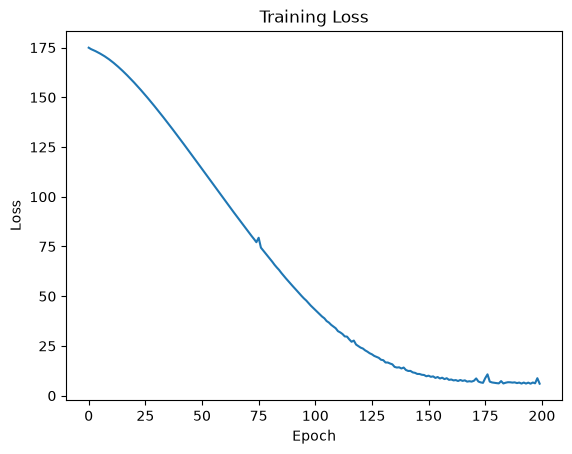

In [375]:
plt.plot(loss_history)
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.show()

In [376]:
def get_reconstruction_errors(model, data_loader):
    model.eval()
    errors = []

    with torch.no_grad():
        for (features,) in data_loader:
            features = features.to(device)
            reconstructed = model(features)
            sample_errors = torch.mean((reconstructed - features) ** 2, dim=1)
            errors.extend(sample_errors.cpu().numpy())

    return np.asarray(errors)


# 정상 학습 데이터의 재구성 오차를 기준으로 이상치 임계값 설정
train_errors = get_reconstruction_errors(autoencoder, train_loader)
threshold = np.percentile(train_errors, 99.65)

# 훈련 데이터 중 이상치만 추출
anomaly_train_mask = train_errors > threshold
anomaly_train_data = train_scaled.loc[anomaly_train_mask].copy()
anomaly_train_data['reconstruction_error'] = train_errors[anomaly_train_mask]

print(f'Threshold: {threshold:.6f}')
print(f'Anomaly count: {len(anomaly_train_data)} / {len(train_scaled)}')

Threshold: 404.619537
Anomaly count: 30 / 8470


In [377]:
# 테스트 데이터 성능 확인

test_loss = evaluate(autoencoder, test_loader, criterion)
print(f'Test loss : {test_loss}')

# 테스트 데이터 중 이상치만 추출
test_errors = get_reconstruction_errors(autoencoder, test_loader)
anomaly_test_mask = test_errors > threshold
anomaly_test_data = test_scaled.loc[anomaly_test_mask].copy()
anomaly_test_data['reconstruction_error'] = test_errors[anomaly_test_mask]

print(f'Threshold: {threshold:.6f}')
print(f'Anomaly count: {len(anomaly_test_data)} / {len(test_scaled)}')

Test loss : 4.77210143028951
Threshold: 404.619537
Anomaly count: 10 / 3469


In [380]:
# 날짜별 예측 이상치 개수
ordered_train_errors = get_reconstruction_errors(autoencoder, train_loader)
ordered_test_errors = get_reconstruction_errors(autoencoder, test_loader)

all_anomaly = np.concatenate([
    ordered_train_errors > threshold,
    ordered_test_errors > threshold
])

prediction_by_date = pd.DataFrame({
    'date': pd.to_datetime(raw_data['working time']).dt.normalize(),
    'predicted_anomaly': all_anomaly
})

# 날짜별 이상치 수 확인
daily_anomaly_counts = (
    prediction_by_date.groupby('date', as_index=False)['predicted_anomaly']
    .sum()
    .rename(columns={'predicted_anomaly': 'predicted_anomaly_count'})
)

# 날짜별 전체 행 수 확인
daily_anomaly_counts = daily_anomaly_counts.merge(
    prediction_by_date.groupby('date').size().rename('total_count'),
    on='date'
)

# result에 없는 날짜도 유지하고, 누락된 날짜의 실제 결함 수는 0으로 처리
result_by_date = (
    result.assign(date=pd.to_datetime(result['working time']).dt.normalize())
    .groupby('date', as_index=False)['defect']
    .sum()
    .rename(columns={'defect': 'actual_defect_count'})
)

daily_anomaly_counts = daily_anomaly_counts.merge(
    result_by_date,
    on='date',
    how='left'
)
daily_anomaly_counts['actual_defect_count'] = (
    daily_anomaly_counts['actual_defect_count']
    .fillna(0)
    .astype(int)
)

# 마지막 행에 숫자형 열의 합계 추가
total_row = daily_anomaly_counts.select_dtypes(include='number').sum().to_dict()
total_row['date'] = '합계'
daily_anomaly_counts = pd.concat(
    [daily_anomaly_counts, pd.DataFrame([total_row])],
    ignore_index=True
)

daily_anomaly_counts

,date,predicted_anomaly_count,total_count,actual_defect_count
0,2020-03-24 00:00:00,0,1200,4
1,2020-03-25 00:00:00,10,1352,8
2,2020-03-26 00:00:00,0,1000,7
3,2020-03-27 00:00:00,10,1648,0
4,2020-03-30 00:00:00,0,1470,4
5,2020-03-31 00:00:00,10,1800,5
6,2020-04-02 00:00:00,0,2000,4
7,2020-04-03 00:00:00,10,800,4
8,2020-04-07 00:00:00,0,669,3
9,합계,40,11939,39


In [363]:
torch.save(autoencoder.state_dict(), 'autoencoder_hy_weights.pth')